In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

2026-03-09 11:47:20,526 - tornado.application - ERROR - Exception in callback functools.partial(<function TCPServer._handle_connection.<locals>.<lambda> at 0x7f95c68bc180>, <Task finished name='Task-5039296' coro=<BaseTCPListener._handle_stream() done, defined at /home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py:655> exception=MemoryError((7002586286238287176,), dtype('uint8'))>)
Traceback (most recent call last):
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/tcpserver.py", line 387, in <lambda>
    gen.convert_yielded(future), lambda f: f.result()
                                           ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py", line 667, in _handle_stream
    await self.o

In [2]:
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import xarray as xr
from xmitgcm import open_mdsdataset
import numpy as np

data_dir = '/data/SO3/edavenport/tpose6/apr2013/run_sens_surface/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

num_diags = 122 #
itPerFile = 72 # 1 day
intervals = range(0,itPerFile*num_diags,itPerFile) # adjoint sensitivity will start at 0 and go to 1 lag (1 interval less than total number of timesteps)
prefix = ['ADJetan','ADJtaux','ADJqnet']
# when prefix is not set, this will read all available files 
# have to ignore unkown vars until we have an available_diagnostics.log that includes ADJrhoinsitu
tpose_ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,prefix=prefix,iters=intervals,ref_date='2013-04-01',delta_t=1200,ignore_unknown_vars=True)
tpose_ds['XC'] = tpose_ds.XC.astype(float)
tpose_ds['YC'] = tpose_ds.YC.astype(float)
tpose_ds['Z'] = tpose_ds.Z.astype(float)
tpose_ds['XG'] = tpose_ds.XG.astype(float)
tpose_ds['YG'] = tpose_ds.YG.astype(float)

### Select Region

In [14]:
# tpose_ds.ADJetan is t, xc, yc
lat_min = -3
lat_max = 3
lon_min = 170 #170E
lon_max = 260 #100W

tpose_ds = tpose_ds.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max),XG=slice(lon_min,lon_max),YG=slice(lat_min,lat_max))

### Meridional Average

In [15]:
ADJetan = tpose_ds.ADJetan.mean(dim='YC')
ADJtaux = tpose_ds.ADJtaux.mean(dim='YC')
ADJqnet = tpose_ds.ADJqnet.mean(dim='YC')

### Temporal Demean and Detrend

In [16]:
from scipy.signal import detrend

ADJetan_detrend = detrend(ADJetan, axis=0)
ADJtaux_detrend = detrend(ADJtaux, axis=0)
ADJqnet_detrend = detrend(ADJqnet, axis=0)

# copy into data array
ADJetan_detrend = xr.DataArray(ADJetan_detrend, coords=ADJetan.coords, dims=ADJetan.dims)
ADJtaux_detrend = xr.DataArray(ADJtaux_detrend, coords=ADJtaux.coords, dims=ADJtaux.dims)
ADJqnet_detrend = xr.DataArray(ADJqnet_detrend, coords=ADJqnet.coords, dims=ADJqnet.dims)

# demean
ADJetan_anom = ADJetan_detrend - ADJetan_detrend.mean(dim='time')
ADJtaux_anom = ADJtaux_detrend - ADJtaux_detrend.mean(dim='time')
ADJqnet_anom = ADJqnet_detrend - ADJqnet_detrend.mean(dim='time')

### Window (in X and T)

In [ ]:
# -----------------------------
# Apply 2D Hann window
# -----------------------------
# wx = xr.DataArray(np.hanning(Nx), dims='lon', coords={'lon':A.lon})
# wt = xr.DataArray(np.hanning(Nt), dims='time', coords={'time':A.time})
# A_win = A * wt * wx

In [121]:
# use a hanning window in t and x dimensions
window_t = np.hanning(ADJetan_anom.shape[0])
window_x = np.hanning(ADJetan_anom.shape[1])
window_2d = np.outer(window_t, window_x)
ADJetan_windowed = ADJetan_anom * window_2d
ADJqnet_windowed = ADJqnet_anom * window_2d

window_t = np.hanning(ADJtaux_anom.shape[0])
window_x = np.hanning(ADJtaux_anom.shape[1])
window_2d = np.outer(window_t, window_x)
ADJtaux_windowed = ADJtaux_anom * window_2d

In [215]:
folder_name = '/home/edavenport/analysis/TPOSE6_Sensitivity/apr2013/surface/'

### 2-D FFT 

In [122]:
# -----------------------------
# Get time and space units (dt and dx) from coordinates
# -----------------------------

dx = np.mean(np.diff(tpose_ds.XC))  # in units of degrees
dt_ns = np.mean(np.diff(tpose_ds.time))              # timedelta64[ns]
dt = dt_ns / np.timedelta64(1, 'D') # convert to float in days

print(dt)    # 1 day
print(dx)    # 1/6 degree


1.0
0.16666665723018612


In [225]:

# -----------------------------
# 2D FFT
# -----------------------------
ETAN_fft = np.fft.fft2(ADJetan_windowed)
ETAN_fft = np.fft.fftshift(ETAN_fft, axes=(0,1))  # shift time and lon axes
Nt = ADJetan_windowed.shape[0]
Nx = ADJetan_windowed.shape[1]
P = np.abs(ETAN_fft)**2 / (Nt*Nx)

In [226]:
# wavenumber / frequency axes
kx = np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))        # deg^-1
omega = np.fft.fftshift(np.fft.fftfreq(Nt, d=dt)) # cycles/day

In [227]:
# -----------------------------
# Normalize for real signal
# -----------------------------
# double all non-zero, non-Nyquist frequencies along time
nonzero_idx = np.where((omega != 0) & (omega != omega.max()))[0]
P[nonzero_idx, :] *= 2

# -----------------------------
# Select only positive omega
# -----------------------------
pos_idx = omega >= 0
P_pos = P[pos_idx, :]
omega_pos = omega[pos_idx]

# Create xarray for plotting
P_da = xr.DataArray(P_pos, dims=['omega','kx'],
                    coords={'omega': omega_pos, 'kx': kx})

(0.0, 0.5)

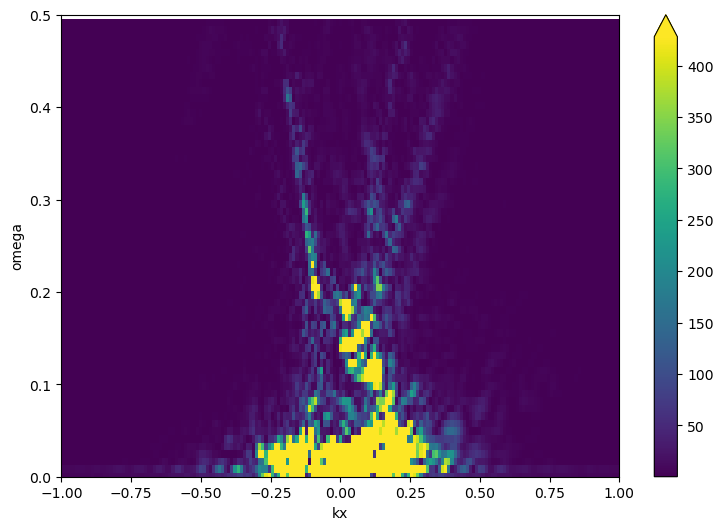

In [126]:
fig, ax = plt.subplots(figsize=(9,6))
P_da.plot(ax=ax,x='kx', y='omega', cmap='viridis',vmax=np.percentile(P_da, 99))
ax.set_xlim(-1,1)
ax.set_ylim(0,0.5)

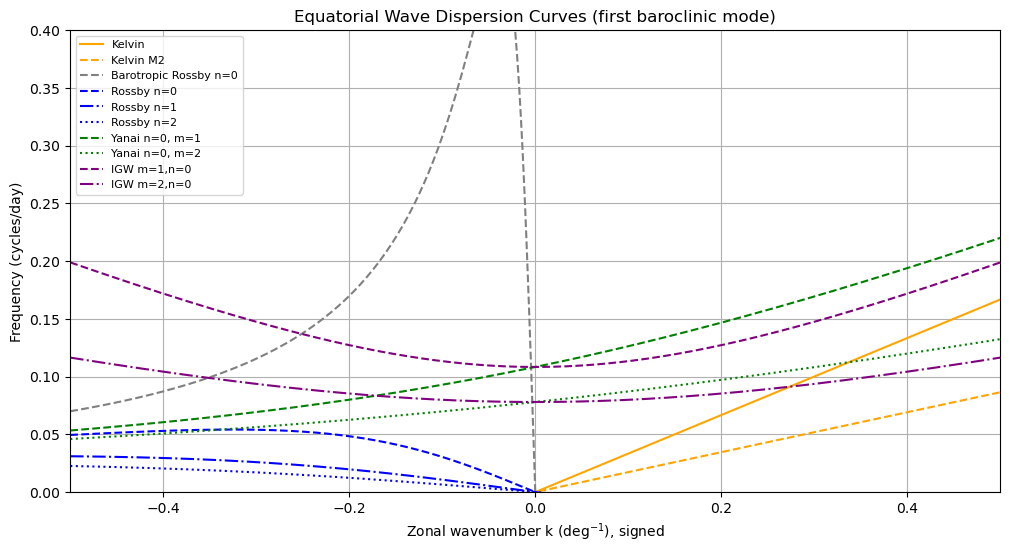

In [193]:
# -----------------------------
# Physical constants
# -----------------------------
g = 9.81            # m/s^2
beta = 2.3e-11      # 1/(m s)
c = 2.7             # first baroclinic mode phase speed (m/s)
c1 = c
c2 = 1.4
deg2m = 111320      # m per degree at equator

# -----------------------------
# Wavenumber array (signed)
# -----------------------------
k_deg = np.linspace(-0.5, 0.5, 1000)   # deg^-1
k_m = k_deg / deg2m                     # convert to 1/m

# -----------------------------
# Helper: convert rad/s → cycles/day
# -----------------------------
def rad_s_to_cpd(omega):
    return omega * 86400 / (2*np.pi)

# -----------------------------
# Kelvin wave (eastward only)
# -----------------------------
omega_kelvin = c * k_m
f_kelvin = rad_s_to_cpd(omega_kelvin)
# M2 Kelvin wave
omega_kelvin_m2 = c2 * k_m             # rad/s
freq_kelvin_m2 = rad_s_to_cpd(omega_kelvin_m2)  # cycles/day
# -----------------------------
# Rossby waves n=0,1,2 (westward)
# Long-wave approximation: ω = -β k / (k^2 + (2n+1)*β/c)
omega_rossby0 = -beta * k_m / (k_m**2 + (1 * beta / c))
omega_rossby1 = -beta * k_m / (k_m**2 + (3 * beta / c))
omega_rossby2 = -beta * k_m / (k_m**2 + (5 * beta / c))
f_rossby0 = rad_s_to_cpd(omega_rossby0)
f_rossby1 = rad_s_to_cpd(omega_rossby1)
f_rossby2 = rad_s_to_cpd(omega_rossby2)

c_barotropic = np.sqrt(9.81 * 4000)  # m/s
omega_barotropic = -beta * k_m / (k_m**2 + 1 * beta / c_barotropic)  # n=0
freq_barotropic_ross = omega_barotropic * 86400 / (2*np.pi)  # cycles/day
# -----------------------------
# Yanai dispersion function (n=0)
# -----------------------------
def yanai_omega_n0(k, c):
    # Matsuno 1966 quadratic, always positive frequency
    omega = 0.5 * (c*k + np.sqrt((c*k)**2 + 4*c*beta))
    return omega

# Compute omega for M1 and M2
omega_yanai_m1 = yanai_omega_n0(k_m, c1)
omega_yanai_m2 = yanai_omega_n0(k_m, c2)

# Convert to cycles/day
def rad_s_to_cpd(omega_rad_s):
    return omega_rad_s * 86400 / (2*np.pi)

f_yanai_m1 = rad_s_to_cpd(omega_yanai_m1)
f_yanai_m2 = rad_s_to_cpd(omega_yanai_m2)
# -----------------------------
# Inertia-gravity waves (IG) n=1,2
# ω = sqrt(c^2 k^2 + (2n+1) β c)
n1, n2, n3 = 1, 2, 3
omega_ig0 = np.sqrt(c**2 * k_m**2 + (2*0+1)*beta*c)
omega_ig1 = np.sqrt(c**2 * k_m**2 + (2*n1+1)*beta*c)
omega_ig2 = np.sqrt(c**2 * k_m**2 + (2*n2+1)*beta*c)
omega_ig3 = np.sqrt(c**2 * k_m**2 + (2*n3+1)*beta*c)
f_ig0 = rad_s_to_cpd(omega_ig0)
f_ig1 = rad_s_to_cpd(omega_ig1)
f_ig2 = rad_s_to_cpd(omega_ig2)
f_ig3 = rad_s_to_cpd(omega_ig3)

# -----------------------------
# Inertia-Gravity Wave (IGW, M2), n=0
omega_igw_m2 = np.sqrt((c2 * k_m)**2 + beta * c2)
freq_igw_m2 = rad_s_to_cpd(omega_igw_m2)
# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12,6))

plt.plot(k_deg, f_kelvin, color='orange', label='Kelvin')
plt.plot(k_deg, freq_kelvin_m2, color='orange', linestyle='--',label='Kelvin M2')
plt.plot(k_deg, freq_barotropic_ross, color='gray', linestyle='--', label='Barotropic Rossby n=0')
plt.plot(k_deg, f_rossby0, color='blue', linestyle='--', label='Rossby n=0')
plt.plot(k_deg, f_rossby1, color='blue', linestyle='-.', label='Rossby n=1')
plt.plot(k_deg, f_rossby2, color='blue', linestyle=':', label='Rossby n=2')

plt.plot(k_deg, f_yanai_m1, color='green', linestyle='--',label='Yanai n=0, m=1')
plt.plot(k_deg, f_yanai_m2, color='green', linestyle=':', label='Yanai n=0, m=2')

plt.plot(k_deg, f_ig0, color='purple', linestyle='--', label='IGW m=1,n=0')
plt.plot(k_deg, freq_igw_m2, color='purple', linestyle='-.', label='IGW m=2,n=0')

plt.xlabel('Zonal wavenumber k (deg$^{-1}$), signed')
plt.ylabel('Frequency (cycles/day)')
plt.title('Equatorial Wave Dispersion Curves (first baroclinic mode)')
plt.xlim([-0.5,0.5])
plt.ylim([0,0.4])
plt.grid(True)
plt.legend(loc='upper left', fontsize=8)
plt.show()

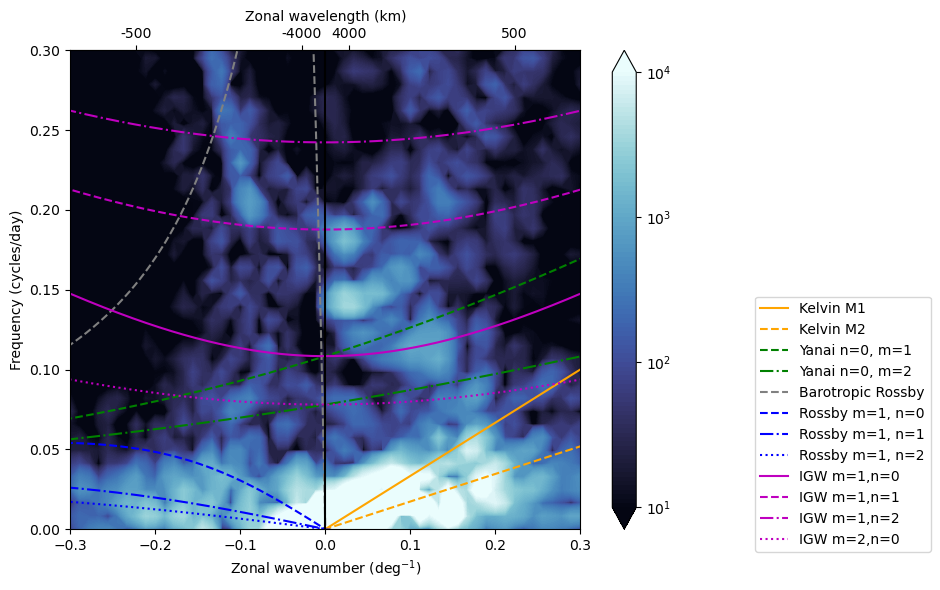

In [228]:
from matplotlib.colors import LogNorm
log_levels = np.logspace(1, 4, 100)
fig, ax = plt.subplots(figsize=(10,6))
cf = P_da.plot.contourf(ax=ax,x='kx', y='omega', cmap=cmo.ice,levels=log_levels,extend='both',norm=LogNorm(vmin=1e1,vmax=1e4))

# set log scale ticks for colorbar
cbar = cf.colorbar
cbar.set_ticks([10, 100, 1000, 10000])

ax.set_xlim(-0.3,0.3)
ax.set_ylim(0,0.3)
ax.set_ylabel('Frequency (cycles/day)')
ax.set_xlabel('Zonal wavenumber (deg$^{-1}$)')
# Overlay dispersion curves
ax.plot(k_deg, f_kelvin, color='orange', label='Kelvin M1')
ax.plot(k_deg, freq_kelvin_m2, color='orange', linestyle='--',label='Kelvin M2')
ax.plot(k_deg, f_yanai_m1, color='green', linestyle='--',label='Yanai n=0, m=1')
ax.plot(k_deg, f_yanai_m2, color='green', linestyle='-.', label='Yanai n=0, m=2')
plt.plot(k_deg, freq_barotropic_ross, color='gray', linestyle='--', label='Barotropic Rossby')
ax.plot(k_deg, f_rossby0, color='blue', linestyle='--', label='Rossby m=1, n=0')
ax.plot(k_deg, f_rossby1, color='blue', linestyle='-.', label='Rossby m=1, n=1')
ax.plot(k_deg, f_rossby2, color='blue', linestyle=':', label='Rossby m=1, n=2')
ax.plot(k_deg, f_ig0, color='m', label='IGW m=1,n=0')
ax.plot(k_deg, f_ig1, color='m', linestyle='--', label='IGW m=1,n=1')
ax.plot(k_deg, f_ig2, color='m', linestyle='-.', label='IGW m=1,n=2')
ax.plot(k_deg, freq_igw_m2, color='m', linestyle=':', label='IGW m=2,n=0')
ax.axvline(0, color='k',label='_nolabel')
ax.legend(bbox_to_anchor=(1.7, 0.5))

# Manually set secondary x-axis ticks
km_ticks = np.array([-4000, -500, 500, 4000])  # desired top-axis tick labels in km
kdeg_for_ticks = deg2m / (1000 * km_ticks)     # convert km → k_deg
# Set secondary axis manually with fixed tick positions
secax = ax.secondary_xaxis('top')
secax.set_xticks(kdeg_for_ticks)                  # positions in deg^-1
secax.set_xticklabels([str(int(wl)) for wl in km_ticks])  # labels in km
secax.set_xlabel('Zonal wavelength (km)')

plt.tight_layout()
fig.savefig(folder_name + 'k_omega_spectrum_ETAN.png', dpi=300)

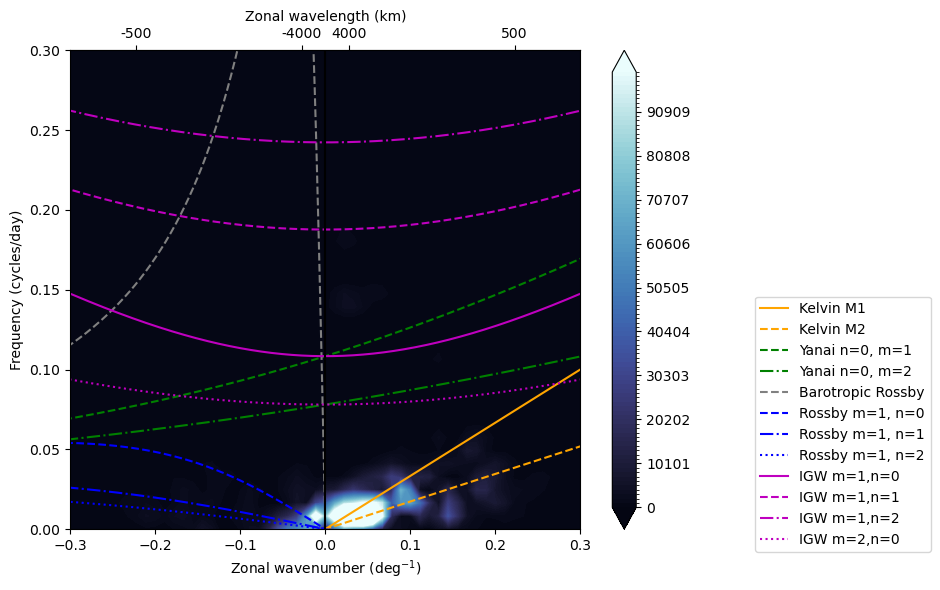

In [230]:
levels = np.linspace(0, 1e5, 100)
fig, ax = plt.subplots(figsize=(10,6))
cf = P_da.plot.contourf(ax=ax,x='kx', y='omega', cmap=cmo.ice,levels=levels,extend='both')
ax.set_xlim(-0.3,0.3)
ax.set_ylim(0,0.3)
ax.set_ylabel('Frequency (cycles/day)')
ax.set_xlabel('Zonal wavenumber (deg$^{-1}$)')
# Overlay dispersion curves
ax.plot(k_deg, f_kelvin, color='orange', label='Kelvin M1')
ax.plot(k_deg, freq_kelvin_m2, color='orange', linestyle='--',label='Kelvin M2')
ax.plot(k_deg, f_yanai_m1, color='green', linestyle='--',label='Yanai n=0, m=1')
ax.plot(k_deg, f_yanai_m2, color='green', linestyle='-.', label='Yanai n=0, m=2')
plt.plot(k_deg, freq_barotropic_ross, color='gray', linestyle='--', label='Barotropic Rossby')
ax.plot(k_deg, f_rossby0, color='blue', linestyle='--', label='Rossby m=1, n=0')
ax.plot(k_deg, f_rossby1, color='blue', linestyle='-.', label='Rossby m=1, n=1')
ax.plot(k_deg, f_rossby2, color='blue', linestyle=':', label='Rossby m=1, n=2')
ax.plot(k_deg, f_ig0, color='m', label='IGW m=1,n=0')
ax.plot(k_deg, f_ig1, color='m', linestyle='--', label='IGW m=1,n=1')
ax.plot(k_deg, f_ig2, color='m', linestyle='-.', label='IGW m=1,n=2')
ax.plot(k_deg, freq_igw_m2, color='m', linestyle=':', label='IGW m=2,n=0')
ax.axvline(0, color='k',label='_nolabel')
ax.legend(bbox_to_anchor=(1.7, 0.5))

# Manually set secondary x-axis ticks
km_ticks = np.array([-4000, -500, 500, 4000])  # desired top-axis tick labels in km
kdeg_for_ticks = deg2m / (1000 * km_ticks)     # convert km → k_deg
# Set secondary axis manually with fixed tick positions
secax = ax.secondary_xaxis('top')
secax.set_xticks(kdeg_for_ticks)                  # positions in deg^-1
secax.set_xticklabels([str(int(wl)) for wl in km_ticks])  # labels in km
secax.set_xlabel('Zonal wavelength (km)')

plt.tight_layout()
fig.savefig(folder_name + 'k_omega_spectrum_ETAN_notlog.png', dpi=300)

### TAUX

In [213]:

# -----------------------------
# 2D FFT
# -----------------------------
TAUX_fft = np.fft.fft2(ADJtaux_windowed)
TAUX_fft = np.fft.fftshift(TAUX_fft, axes=(0,1))  # shift time and lon axes
Nt = ADJtaux_windowed.shape[0]
Nx = ADJtaux_windowed.shape[1]
P = np.abs(TAUX_fft)**2 / (Nt*Nx)

# wavenumber / frequency axes
kx = np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))        # deg^-1
omega = np.fft.fftshift(np.fft.fftfreq(Nt, d=dt)) # cycles/day

# -----------------------------
# Normalize for real signal
# -----------------------------
# double all non-zero, non-Nyquist frequencies along time
nonzero_idx = np.where((omega != 0) & (omega != omega.max()))[0]
P[nonzero_idx, :] *= 2

# -----------------------------
# Select only positive omega
# -----------------------------
pos_idx = omega >= 0
P_pos = P[pos_idx, :]
omega_pos = omega[pos_idx]

# Create xarray for plotting
P_da = xr.DataArray(P_pos, dims=['omega','kx'],
                    coords={'omega': omega_pos, 'kx': kx})

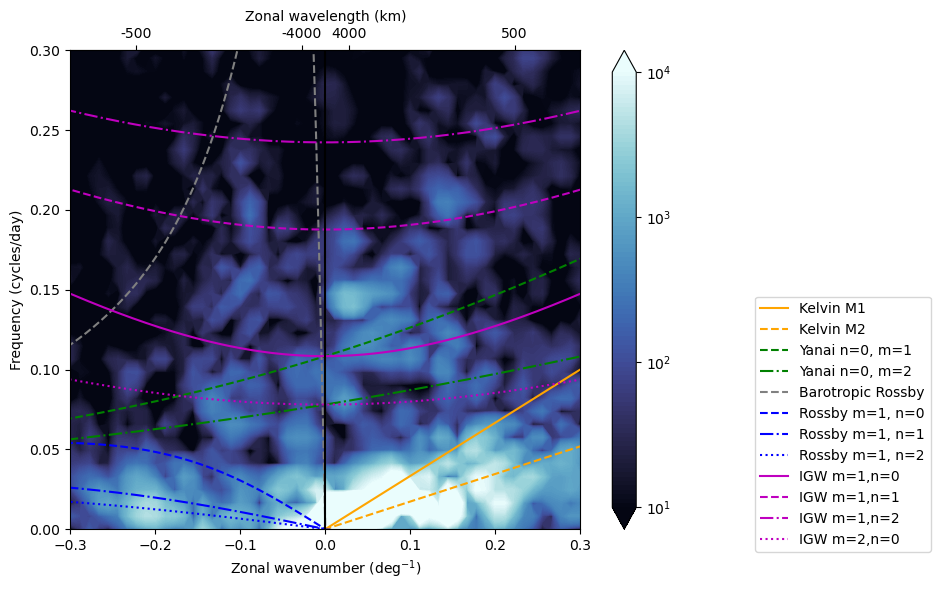

In [216]:
from matplotlib.colors import LogNorm
log_levels = np.logspace(1, 4, 100)
fig, ax = plt.subplots(figsize=(10,6))
cf = P_da.plot.contourf(ax=ax,x='kx', y='omega', cmap=cmo.ice,levels=log_levels,extend='both',norm=LogNorm(vmin=1e1,vmax=1e4))

# set log scale ticks for colorbar
cbar = cf.colorbar
cbar.set_ticks([10, 100, 1000, 10000])

ax.set_xlim(-0.3,0.3)
ax.set_ylim(0,0.3)
ax.set_ylabel('Frequency (cycles/day)')
ax.set_xlabel('Zonal wavenumber (deg$^{-1}$)')
# Overlay dispersion curves
ax.plot(k_deg, f_kelvin, color='orange', label='Kelvin M1')
ax.plot(k_deg, freq_kelvin_m2, color='orange', linestyle='--',label='Kelvin M2')
ax.plot(k_deg, f_yanai_m1, color='green', linestyle='--',label='Yanai n=0, m=1')
ax.plot(k_deg, f_yanai_m2, color='green', linestyle='-.', label='Yanai n=0, m=2')
plt.plot(k_deg, freq_barotropic_ross, color='gray', linestyle='--', label='Barotropic Rossby')
ax.plot(k_deg, f_rossby0, color='blue', linestyle='--', label='Rossby m=1, n=0')
ax.plot(k_deg, f_rossby1, color='blue', linestyle='-.', label='Rossby m=1, n=1')
ax.plot(k_deg, f_rossby2, color='blue', linestyle=':', label='Rossby m=1, n=2')
ax.plot(k_deg, f_ig0, color='m', label='IGW m=1,n=0')
ax.plot(k_deg, f_ig1, color='m', linestyle='--', label='IGW m=1,n=1')
ax.plot(k_deg, f_ig2, color='m', linestyle='-.', label='IGW m=1,n=2')
ax.plot(k_deg, freq_igw_m2, color='m', linestyle=':', label='IGW m=2,n=0')
ax.axvline(0, color='k',label='_nolabel')
ax.legend(bbox_to_anchor=(1.7, 0.5))

# Manually set secondary x-axis ticks
km_ticks = np.array([-4000, -500, 500, 4000])  # desired top-axis tick labels in km
kdeg_for_ticks = deg2m / (1000 * km_ticks)     # convert km → k_deg
# Set secondary axis manually with fixed tick positions
secax = ax.secondary_xaxis('top')
secax.set_xticks(kdeg_for_ticks)                  # positions in deg^-1
secax.set_xticklabels([str(int(wl)) for wl in km_ticks])  # labels in km
secax.set_xlabel('Zonal wavelength (km)')

plt.tight_layout()
fig.savefig(folder_name + 'k_omega_spectrum_TAUX.png', dpi=300)

### 

In [ ]:
cluster.close()
client.shutdown()